In [7]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load Data
fwd = pd.read_excel("../data/MON_DEFL_DROP_DATA.xlsx")
exp = pd.read_excel("../data/EXPERIMENT_SECTION.xlsx")

print("FWD shape:", fwd.shape)
print("EXP shape:", exp.shape)

FWD shape: (65534, 25)
EXP shape: (7630, 25)


In [8]:
# Fix SHRP_ID format mismatch
fwd['SHRP_ID'] = fwd['SHRP_ID'].astype(str).str.zfill(4)

# Keep only useful columns from EXP
exp_clean = exp[['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 
                 'PAVEMENT_FAMILY']].drop_duplicates()

# Drop useless FWD columns safely
columns_to_drop = ['PEAK_DEFL_8', 'PEAK_DEFL_9', 'NON_DECREASING_DEFL', 
                   'NON_DECREASING_DEFL_EXP', 'STATE_CODE_EXP', 
                   'LANE_NO_EXP', 'DROP_HEIGHT_EXP', 'DEFL_UNIT_ID']
fwd = fwd.drop(columns=columns_to_drop, errors='ignore')

# Merge
df2 = pd.merge(fwd, exp_clean, 
               on=['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO'], 
               how='inner')

# Drop any remaining nulls
df2 = df2.dropna()

print("Shape after merge and clean:", df2.shape)

Shape after merge and clean: (65534, 18)


In [9]:
# Encode categorical variables
le_pav = LabelEncoder()
df2['PAVEMENT_FAMILY_ENC'] = le_pav.fit_transform(df2['PAVEMENT_FAMILY'])

le_lane = LabelEncoder()
df2['LANE_NO_ENC'] = le_lane.fit_transform(df2['LANE_NO'])

# Define features for clustering
features2 = ['PEAK_DEFL_1', 'PEAK_DEFL_2', 'PEAK_DEFL_3', 
             'PEAK_DEFL_4', 'PEAK_DEFL_5', 'PEAK_DEFL_6', 
             'PEAK_DEFL_7', 'DROP_LOAD', 'DROP_HEIGHT',
             'PAVEMENT_FAMILY_ENC', 'LANE_NO_ENC']

X2 = df2[features2]

# Standardize features (Critical for K-Means)
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)

print("Features standardized and ready for clustering.")

Features standardized and ready for clustering.


In [10]:
# Train K-Means Clustering Model (Unsupervised)
# n_init=10 ensures the algorithm runs 10 times with different centroid seeds
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df2['CLUSTER'] = kmeans.fit_predict(X2_scaled)

# Calculate average deflection per cluster to determine Good/Fair/Poor dynamically
df2['AVG_DEFL'] = df2[['PEAK_DEFL_1','PEAK_DEFL_2','PEAK_DEFL_3',
                       'PEAK_DEFL_4','PEAK_DEFL_5','PEAK_DEFL_6',
                       'PEAK_DEFL_7']].mean(axis=1)

# Sort clusters by average deflection
cluster_means = df2.groupby('CLUSTER')['AVG_DEFL'].mean().sort_values()

# The cluster with the lowest average deflection is "Good", highest is "Poor"
health_mapping = {
    cluster_means.index[0]: 'Good',
    cluster_means.index[1]: 'Fair',
    cluster_means.index[2]: 'Poor'
}

df2['HEALTH'] = df2['CLUSTER'].map(health_mapping)

print("Cluster to Health Mapping:", health_mapping)
print("\nDynamic Health Distribution:")
print(df2['HEALTH'].value_counts())
print("\nSample Data:")
print(df2[['SHRP_ID', 'AVG_DEFL', 'HEALTH']].head())

Cluster to Health Mapping: {np.int32(2): 'Good', np.int32(0): 'Fair', np.int32(1): 'Poor'}

Dynamic Health Distribution:
HEALTH
Fair    25204
Good    21164
Poor    19166
Name: count, dtype: int64

Sample Data:
  SHRP_ID    AVG_DEFL HEALTH
0    0101  406.285714   Poor
1    0101  201.571429   Fair
2    0101  202.000000   Fair
3    0101  202.714286   Fair
4    0101  202.285714   Fair


Unsupervised model and preprocessors saved!


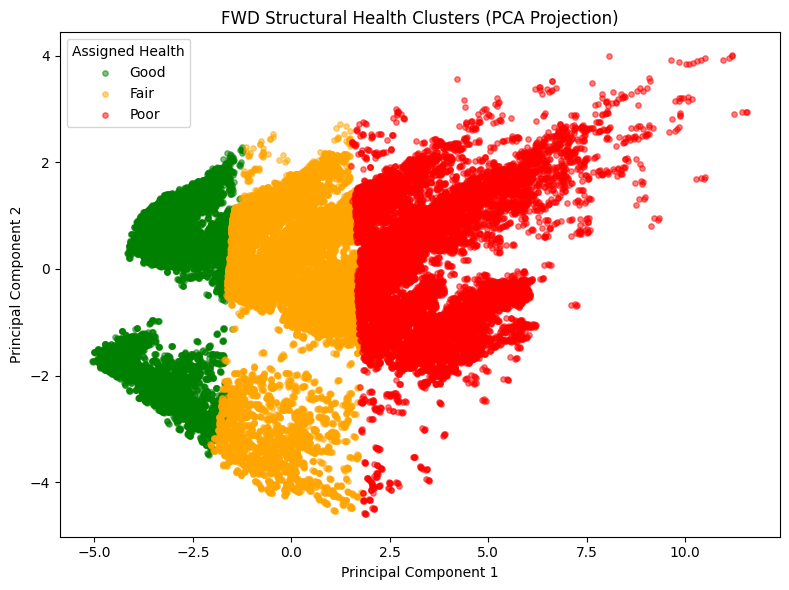

In [11]:
# Save the model and preprocessors for the RHI pipeline
joblib.dump(kmeans, '../models/fwd_kmeans_model.pkl')
joblib.dump(scaler, '../models/fwd_scaler.pkl')
joblib.dump(le_pav, '../models/fwd_le_pav.pkl')
joblib.dump(le_lane, '../models/fwd_le_lane.pkl')
joblib.dump(health_mapping, '../models/fwd_health_mapping.pkl')
print("Unsupervised model and preprocessors saved!")

# Visualize Clusters using PCA (reducing multidimensional data to 2D for plotting)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X2_scaled)
df2['PCA1'] = X_pca[:, 0]
df2['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
colors = {'Good': 'green', 'Fair': 'orange', 'Poor': 'red'}

for health_status in ['Good', 'Fair', 'Poor']:
    subset = df2[df2['HEALTH'] == health_status]
    plt.scatter(subset['PCA1'], subset['PCA2'], 
                label=health_status, alpha=0.5, 
                color=colors[health_status], s=15)

plt.title("FWD Structural Health Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Assigned Health")
plt.tight_layout()
plt.savefig('../outputs/fwd_kmeans_clusters.png', dpi=150)
plt.show()

In [12]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Calculate clustering evaluation metrics
# Note: Silhouette score can be memory-intensive on 65k+ rows, so we evaluate it on a random sample
sil_score = silhouette_score(X2_scaled, df2['CLUSTER'], sample_size=10000, random_state=42)
ch_score = calinski_harabasz_score(X2_scaled, df2['CLUSTER'])
db_score = davies_bouldin_score(X2_scaled, df2['CLUSTER'])

print("============================================")
print("     MODEL 2 CLUSTERING EVALUATION REPORT   ")
print("============================================")
print(f"Silhouette Score      : {sil_score:.4f}  | Range: -1 to 1 (closer to 1 is better)")
print(f"Calinski-Harabasz     : {ch_score:.2f} | Higher is better (measures cluster density/separation)")
print(f"Davies-Bouldin Index  : {db_score:.4f}  | Closer to 0 is better (lower means clusters are distinct)")
print("============================================")

     MODEL 2 CLUSTERING EVALUATION REPORT   
Silhouette Score      : 0.2864  | Range: -1 to 1 (closer to 1 is better)
Calinski-Harabasz     : 45953.49 | Higher is better (measures cluster density/separation)
Davies-Bouldin Index  : 1.2538  | Closer to 0 is better (lower means clusters are distinct)
